In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

df = pd.read_csv('regression.csv')
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


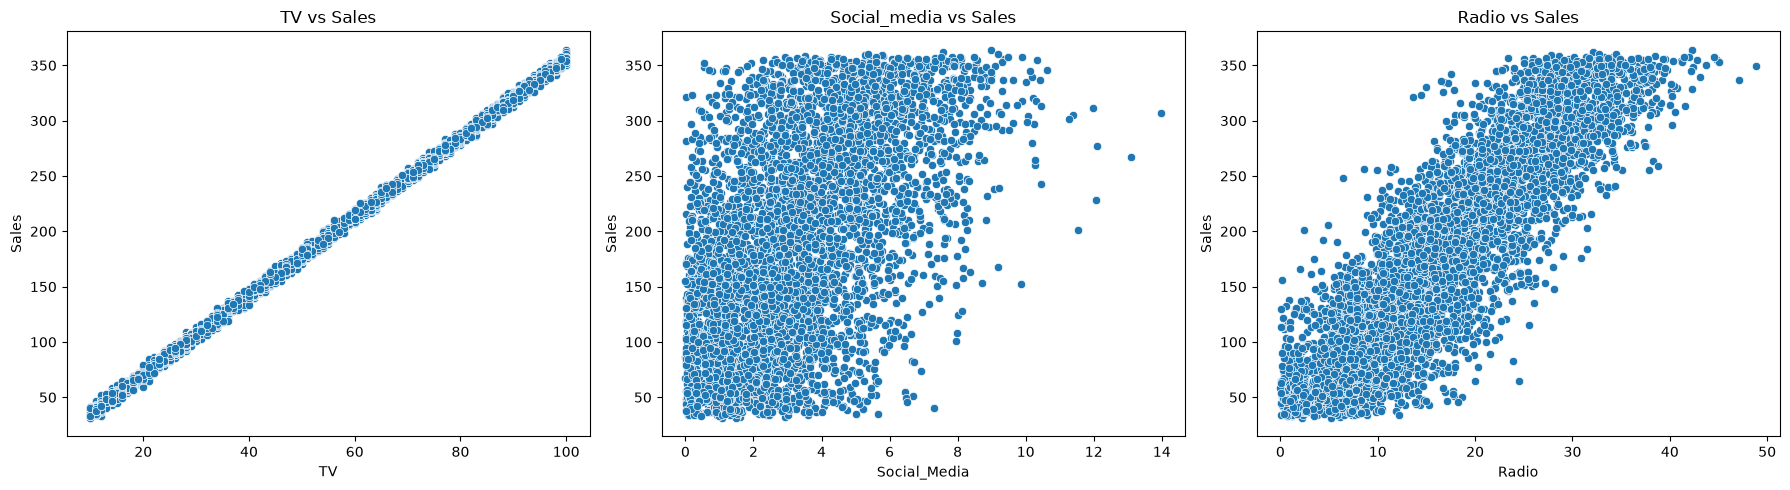

In [2]:
plt.rcParams['figure.figsize'] = (18,5)
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0])
sns.scatterplot(data=df, x='Social_Media', y='Sales', ax=axes[1])
sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[2])
axes[0].set_title('TV vs Sales')
axes[1].set_title('Social_media vs Sales')
axes[2].set_title('Radio vs Sales')
plt.tight_layout()
plt.show()


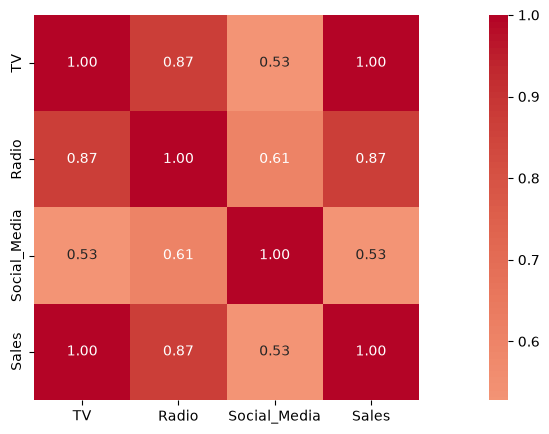

Social_Media    0.528906
Radio           0.869105
TV              0.999497
Sales           1.000000
Name: Sales, dtype: float64


In [3]:
corr = df[['TV','Radio','Social_Media','Sales']].corr()
sns.heatmap(corr,annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.show()
print(corr['Sales'].sort_values(ascending=True))

In [4]:
df_clean = df[['TV','Sales']].dropna()
X = df_clean['TV']
y = df_clean['Sales']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:15:39   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1263      0.101     -1.257      0.2

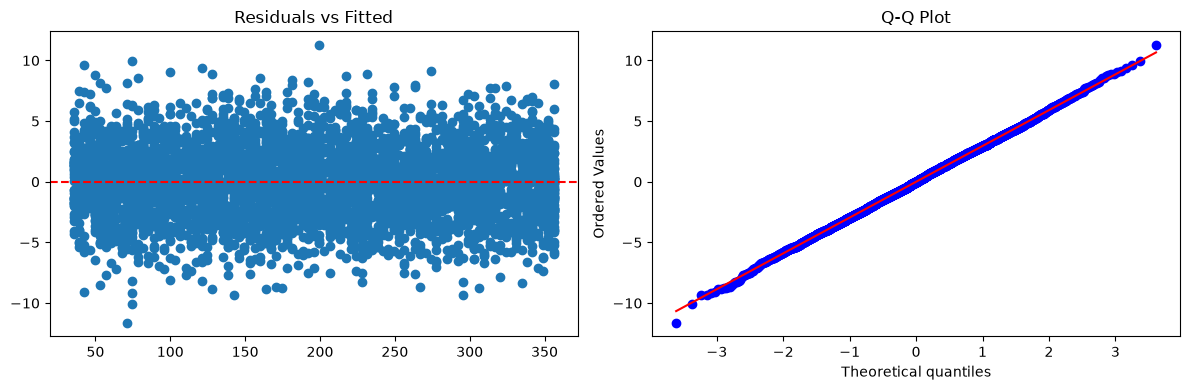

In [5]:
residuals = model.resid
fitted = model.fittedvalues
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].scatter(fitted, residuals)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Fitted')
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()


### Interpretation

R-squared = 0.999: 99.9% of sales variation explained by TV spend.
TV coefficient = 3.5614, p < 0.001: Statistically significant positive impact.
F-statistic confirms model is highly significant.

### Business Recommendation
Allocate majority of marketing budget to TV channel. Each additional unit spent on TV drives predictable increase in Sales. Test TV + Radio combination next to capture remaining 0.1% variation.
    